**EBM model**

In [ ]:
!pip install interpret
# EBM Model
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 56.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 18.2 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=4010717 sha256=894b0052820917f830082b2ee17daffec8bfa41a97d9781653e77a274577fb34
  Stored in directory: /root/.cache/pip/wheels/0c/db/f6/9dcb225e9adf45dfef713542769

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

In [ ]:
# selected features
X = df_balanced[selected]
y = df_balanced['at_risk']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Create EBM model
ebm_model = ExplainableBoostingClassifier(
    random_state=42,
    interactions=10
)

# Train model
ebm_model.fit(X_train, y_train)

ExplainableBoostingClassifier(interactions=10)

**evaluation**

In [ ]:
# Predictions
y_pred_ebm = ebm_model.predict(X_test)

# Accuracy
print("EBM Accuracy:", accuracy_score(y_test, y_pred_ebm))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_ebm))

EBM Accuracy: 0.9313814153289622

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4423
           1       0.93      0.93      0.93      4423

    accuracy                           0.93      8846
   macro avg       0.93      0.93      0.93      8846
weighted avg       0.93      0.93      0.93      8846



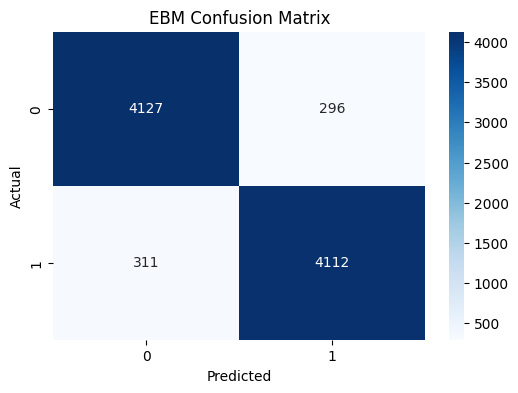

In [ ]:
# Confusion Matrix
cm_ebm = confusion_matrix(y_test, y_pred_ebm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_ebm, annot=True, fmt='d', cmap='Blues')
plt.title("EBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

** explainability techniques**

1. Global Feature Importance

In [ ]:
from interpret import show

# Global explanation
ebm_global = ebm_model.explain_global()

show(ebm_global)

2. Local Explanation

In [ ]:
# Local explanation for first 5 samples
ebm_local = ebm_model.explain_local(X_test[:5], y_test[:5])

show(ebm_local)

3. Feature Shape Functions

In [ ]:
# Global explanation
ebm_global = ebm_model.explain_global()

# Visualize first 5 features
for i in range(min(5, len(X.columns))):

    print(f"\nFeature: {X.columns[i]}")


    fig = ebm_global.visualize(i)

    fig.show()


Feature: age



Feature: chest_pain



Feature: high_blood_pressure



Feature: irregular_heartbeat



Feature: shortness_of_breath


4. Pairwise Interaction Explanations

In [ ]:
# Train EBM with interactions
ebm_model_interactions = ExplainableBoostingClassifier(
    random_state=42,
    interactions=10
)

# Fit model
ebm_model_interactions.fit(X_train, y_train)

# Global explanation with interactions
interaction_exp = ebm_model_interactions.explain_global()

show(interaction_exp)

5. Permutation Feature Importance

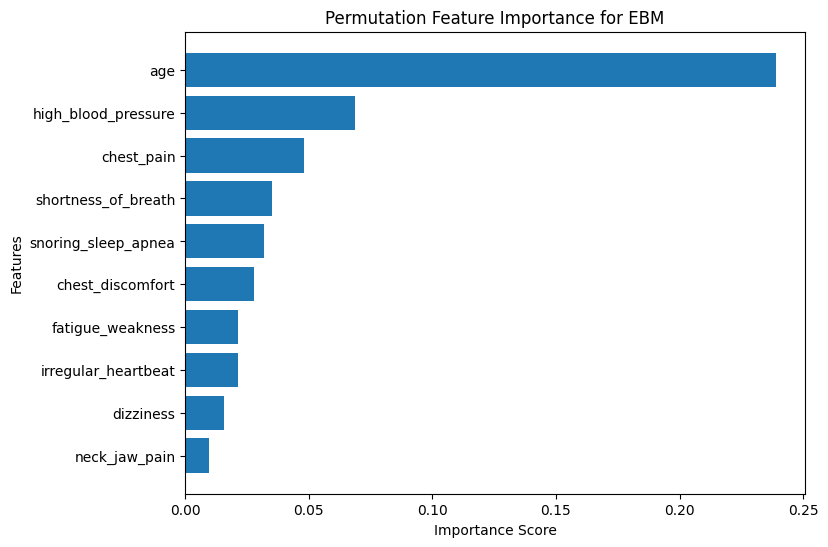

In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance
perm_importance = permutation_importance(
    ebm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean
})

# Sort values
importance_df = importance_df.sort_values(by='Importance', ascending=False)
# Plot
plt.figure(figsize=(8,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Permutation Feature Importance for EBM')
plt.gca().invert_yaxis()
plt.show()